In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import patsy
import missingno as msno

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = sns.color_palette("crest", 8)
plt.rcParams["figure.dpi"] = 110

In [2]:
df_depression = pd.read_csv("../resources/depression_dataset.csv")
df_anxiety = pd.read_csv("../resources/anxiety_dataset.csv")

print("df_depression:", df_depression.shape)
print("df_anxiety:  ", df_anxiety.shape)
df_depression.head()

df_depression: (4891, 29)
df_anxiety:   (4891, 29)


,Cardiometabolic Burden,Socioeconomic Status,Depression,Education,Occupation,Partner occupation,Age,Division,Residence,Religion,Children,Family size,Household Autonomy,Financial Decision-Making,IPV Attitude,Insurance,Internet,Contraceptive,Abortion,Pregnant,Menopause,Sexual activity,Postpartum,CASEID,Cluster number,Sampling weight,PSU,Stratum,Religion_imputed
0,3,5,1,3,0.0,1,3,1,1,1.0,2,1,3,1,0,0.0,0,0.0,1,0,0,0,0,1 1 3,1,0.156207,1,1,0
1,0,4,1,0,1.0,2,3,1,1,2.0,1,1,3,0,0,0.0,0,2.0,0,0,0,1,0,1 18 2,1,0.156207,1,1,0
2,0,4,0,2,1.0,2,1,1,1,1.0,1,1,0,0,0,0.0,0,0.0,0,1,0,1,0,1 35 2,1,0.156207,1,1,0
3,0,4,0,2,0.0,2,2,1,1,2.0,0,1,3,0,0,0.0,2,0.0,0,0,0,1,0,1 52 2,1,0.156207,1,1,0
4,1,5,0,2,0.0,2,3,1,1,2.0,1,1,3,0,0,0.0,0,0.0,1,0,0,0,0,1 69 2,1,0.156207,1,1,0


## 1. Survey Design Overview

In [3]:
design_summary = pd.DataFrame({
    "n_obs": [len(df_depression)],
    "unique_PSU": [df_depression["PSU"].nunique()],
    "unique_Cluster": [df_depression["Cluster number"].nunique()],
    "unique_Stratum": [df_depression["Stratum"].nunique()],
    "weight_min": [df_depression["Sampling weight"].min()],
    "weight_max": [df_depression["Sampling weight"].max()],
    "weight_mean": [df_depression["Sampling weight"].mean()],
    "sum_of_weights": [df_depression["Sampling weight"].sum()],
})
design_summary.index = ["depression sample"]
design_summary

,n_obs,unique_PSU,unique_Cluster,unique_Stratum,weight_min,weight_max,weight_mean,sum_of_weights
depression sample,4891,674,674,16,0.091325,3.891736,0.993047,4856.99414


#### This confirms the our finding from notebook `2. Feature Engineering.ipynb`:
We can use `PSU` instead of `Cluster number`

In [4]:
w = df_depression["Sampling weight"].values
deff_weighting = (len(w) * np.sum(w**2)) / (np.sum(w)**2)
n_eff = len(w) / deff_weighting
print(f"Weighting-only design effect (Kish):  {deff_weighting:.3f}")
print(f"Implied effective sample size:        {n_eff:,.0f}  (of {len(w):,} nominal)")

cluster_sizes = df_depression.groupby("PSU").size()
print(f"\nClusters: {df_depression['PSU'].nunique()}, smallest cluster: {cluster_sizes.min()} respondents")

Weighting-only design effect (Kish):  1.253
Implied effective sample size:        3,904  (of 4,891 nominal)

Clusters: 674, smallest cluster: 2 respondents


## 2. Missingness: Structural Sub-Sampling vs. Item-Level

In [5]:
raw = pd.read_csv("../resources/full_dataset.csv")
raw = raw[raw["S111A"] == 1]
print("Eligible currently-married women (pre-completeness-filter):", raw.shape[0])

diabetes_cols   = ["SB267", "SB236", "SB240"]
hyper_cols      = ["WBP24", "WBP25", "WBP16", "WBP19"]
obesity_cols    = ["HA40"]

biomarker_incomplete = (
    (raw[diabetes_cols].isna().sum(axis=1) >= 3) |
    (raw[hyper_cols].isna().sum(axis=1) >= 4) |
    (raw[obesity_cols].isna().sum(axis=1) >= 1)
)

depression_missing = raw["MTH22"].isna()
occ_ins_abuse_missing = raw[["V744A","V744B","V744C","V744D","V744E"]].isna().all(axis=1)
autonomy_partner_missing = raw[["V743A","V743B","V743D"]].isna().all(axis=1)

overlap = pd.DataFrame({
    "block size": [depression_missing.sum(), occ_ins_abuse_missing.sum(), autonomy_partner_missing.sum()],
    "within biomarker-incomplete": [
        (depression_missing & biomarker_incomplete).sum(),
        (occ_ins_abuse_missing & biomarker_incomplete).sum(),
        (autonomy_partner_missing & biomarker_incomplete).sum(),
    ],
}, index=["Depression/Anxiety (MTH22/24) missing", "Occupation+Insurance+Abuse-attitudes missing (all-NaN block)",
          "Household-decision items (V743A/B/D) missing (all-NaN block)"])
overlap["% explained by biomarker sub-sample"] = (overlap["within biomarker-incomplete"] / overlap["block size"] * 100).round(1)
overlap

Eligible currently-married women (pre-completeness-filter): 28537


,block size,within biomarker-incomplete,% explained by biomarker sub-sample
Depression/Anxiety (MTH22/24) missing,9550,9550,100.0
Occupation+Insurance+Abuse-attitudes missing (all-NaN block),9550,9550,100.0
Household-decision items (V743A/B/D) missing (all-NaN block),9550,9550,100.0


Unchanged conclusion from the previous pass: the depression/anxiety, occupation/insurance/IPV-attitude block is missing for exactly the same women who lack biomarkers (same extended-module sub-sample), and the residual household-decision-item missingness is now driven purely by that same overlap — with currently-married-only filtering, there's no longer a separate "not married, item doesn't apply" component to it.

In [6]:
weight_like_cols = [c for c in raw.columns if c.upper() in ("V005", "SW", "BW", "MW")]
print("Weight-like columns present in the extract:", weight_like_cols)

Weight-like columns present in the extract: ['V005']


### 2.1 Verifying the fixes [RESOLVED]

**Marital status / Partner occupation collinearity** — resolved as a side effect of the currently-married-only filter, not by a targeted fix: `Marital status` is now constant across the whole sample and has been dropped from the pipeline entirely.

In [7]:
print("'Marital status' column present in analytic data?", "Marital status" in df_depression.columns)
print("Partner occupation categories now:", sorted(df_depression["Partner occupation"].unique()))

'Marital status' column present in analytic data? False
Partner occupation categories now: [np.int64(1), np.int64(2), np.int64(3)]


**`Autonomy` silent-zero bug** — the underlying cause (not-currently-married women with all 4 items structurally missing) no longer exists in the sample, since everyone is now currently married. But the *fix itself* was about something broader: `V743F`'s "no earnings" case creates a real denominator mismatch regardless of marital status, and that's still live. Confirmed resolved below — `Household Autonomy` is now built from `V743A`/`V743B`/`V743D` only (zero missingness, no denominator inconsistency), and the `V743F` information is preserved separately in `Financial Decision-Making` rather than discarded.

In [8]:
print("Household Autonomy — any missing?", df_depression["Household Autonomy"].isna().sum())
print("Household Autonomy range:", sorted(df_depression["Household Autonomy"].unique()))
print()
print("Financial Decision-Making distribution (2 = 'No earnings', kept as its own category):")
print(df_depression["Financial Decision-Making"].value_counts().sort_index())
print(f"\n'No earnings' respondents: {(df_depression['Financial Decision-Making']==2).sum()} "
      f"({(df_depression['Financial Decision-Making']==2).mean()*100:.1f}% of the sample) — "
      "no longer forced into the Household Autonomy sum with a mismatched denominator.")

Household Autonomy — any missing? 0
Household Autonomy range: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Financial Decision-Making distribution (2 = 'No earnings', kept as its own category):
Financial Decision-Making
0    1586
1    3241
2      64
Name: count, dtype: int64

'No earnings' respondents: 64 (1.3% of the sample) — no longer forced into the Household Autonomy sum with a mismatched denominator.


**`IPV Attitude` don't-know handling [NEW]** — now a 3-level variable instead of binary, so "don't know" responses get their own category rather than being silently folded into "does not justify" as before.

In [9]:
print("IPV Attitude distribution:")
print(df_depression["IPV Attitude"].value_counts().sort_index())
print(f"\n'Uncertain' (don't know, never affirms): {(df_depression['IPV Attitude']==1).sum()} "
      f"({(df_depression['IPV Attitude']==1).mean()*100:.1f}% of the sample)")

IPV Attitude distribution:
IPV Attitude
0    4177
1      62
2     652
Name: count, dtype: int64

'Uncertain' (don't know, never affirms): 62 (1.3% of the sample)


## 3. Univariate Distributions (Design-Weighted)

In [10]:
def weighted_props(data, col, weight_col="Sampling weight"):
    g = data.groupby(col, dropna=False)[weight_col].sum()
    return (g / g.sum() * 100).sort_index()

def unweighted_props(data, col):
    g = data[col].value_counts(dropna=False)
    return (g / g.sum() * 100).sort_index()

def compare_bar(data, col, ax, title=None, labels=None):
    w = weighted_props(data, col)
    u = unweighted_props(data, col)
    idx = w.index
    x = np.arange(len(idx))
    width = 0.38
    ax.bar(x - width/2, u.reindex(idx).values, width, label="Unweighted", color=PALETTE[2])
    ax.bar(x + width/2, w.reindex(idx).values, width, label="Weighted (V005)", color=PALETTE[6])
    ax.set_xticks(x)
    tick_labels = [labels[i] for i in idx] if labels else [str(i) for i in idx]
    ax.set_xticklabels(tick_labels, rotation=0)
    ax.set_ylabel("%")
    ax.set_title(title or col)
    ax.legend(fontsize=8)

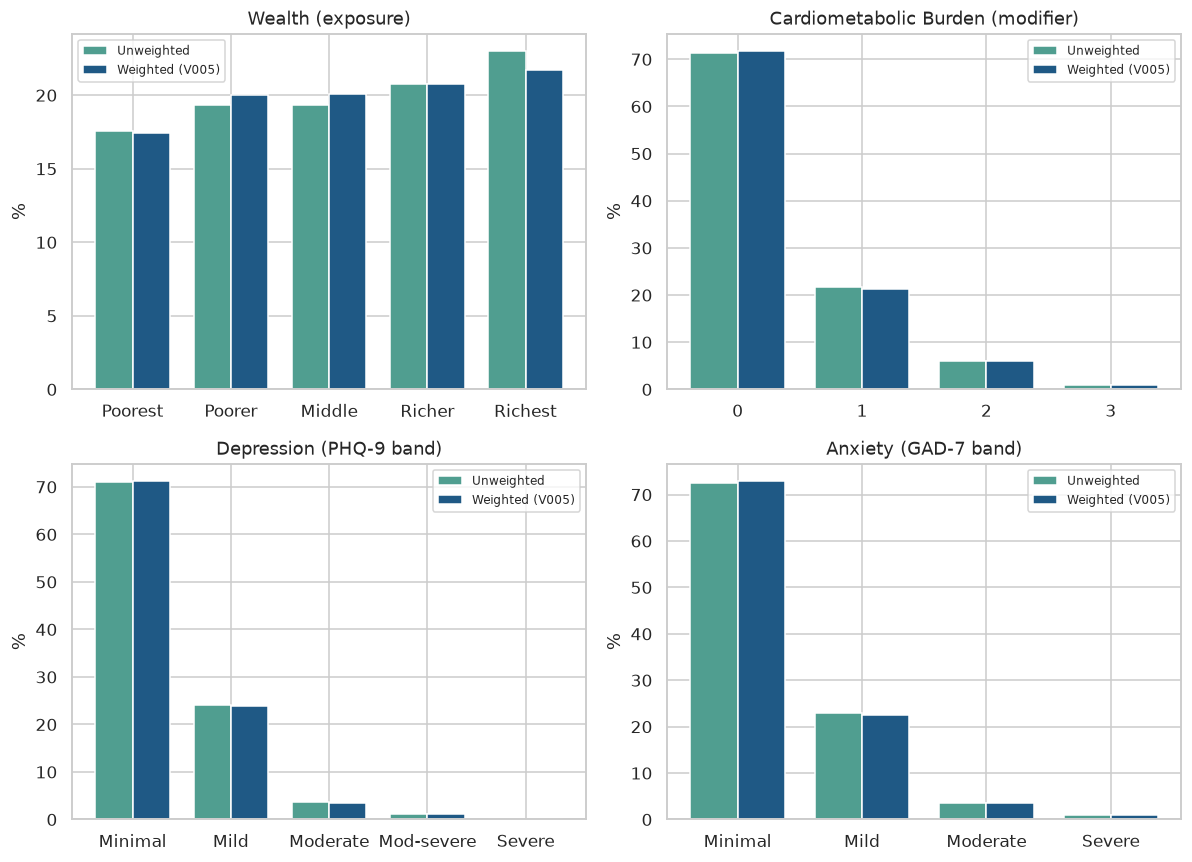

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

compare_bar(df_depression, "Socioeconomic Status", axes[0,0], "Wealth (exposure)",
            {1:"Poorest",2:"Poorer",3:"Middle",4:"Richer",5:"Richest"})
compare_bar(df_depression, "Cardiometabolic Burden", axes[0,1], "Cardiometabolic Burden (modifier)",
            {0:"0",1:"1",2:"2",3:"3"})
compare_bar(df_depression, "Depression", axes[1,0], "Depression (PHQ-9 band)",
            {0:"Minimal",1:"Mild",2:"Moderate",3:"Mod-severe",4:"Severe"})
compare_bar(df_anxiety, "Anxiety", axes[1,1], "Anxiety (GAD-7 band)",
            {0:"Minimal",1:"Mild",2:"Moderate",3:"Severe"})

plt.tight_layout()
plt.show()

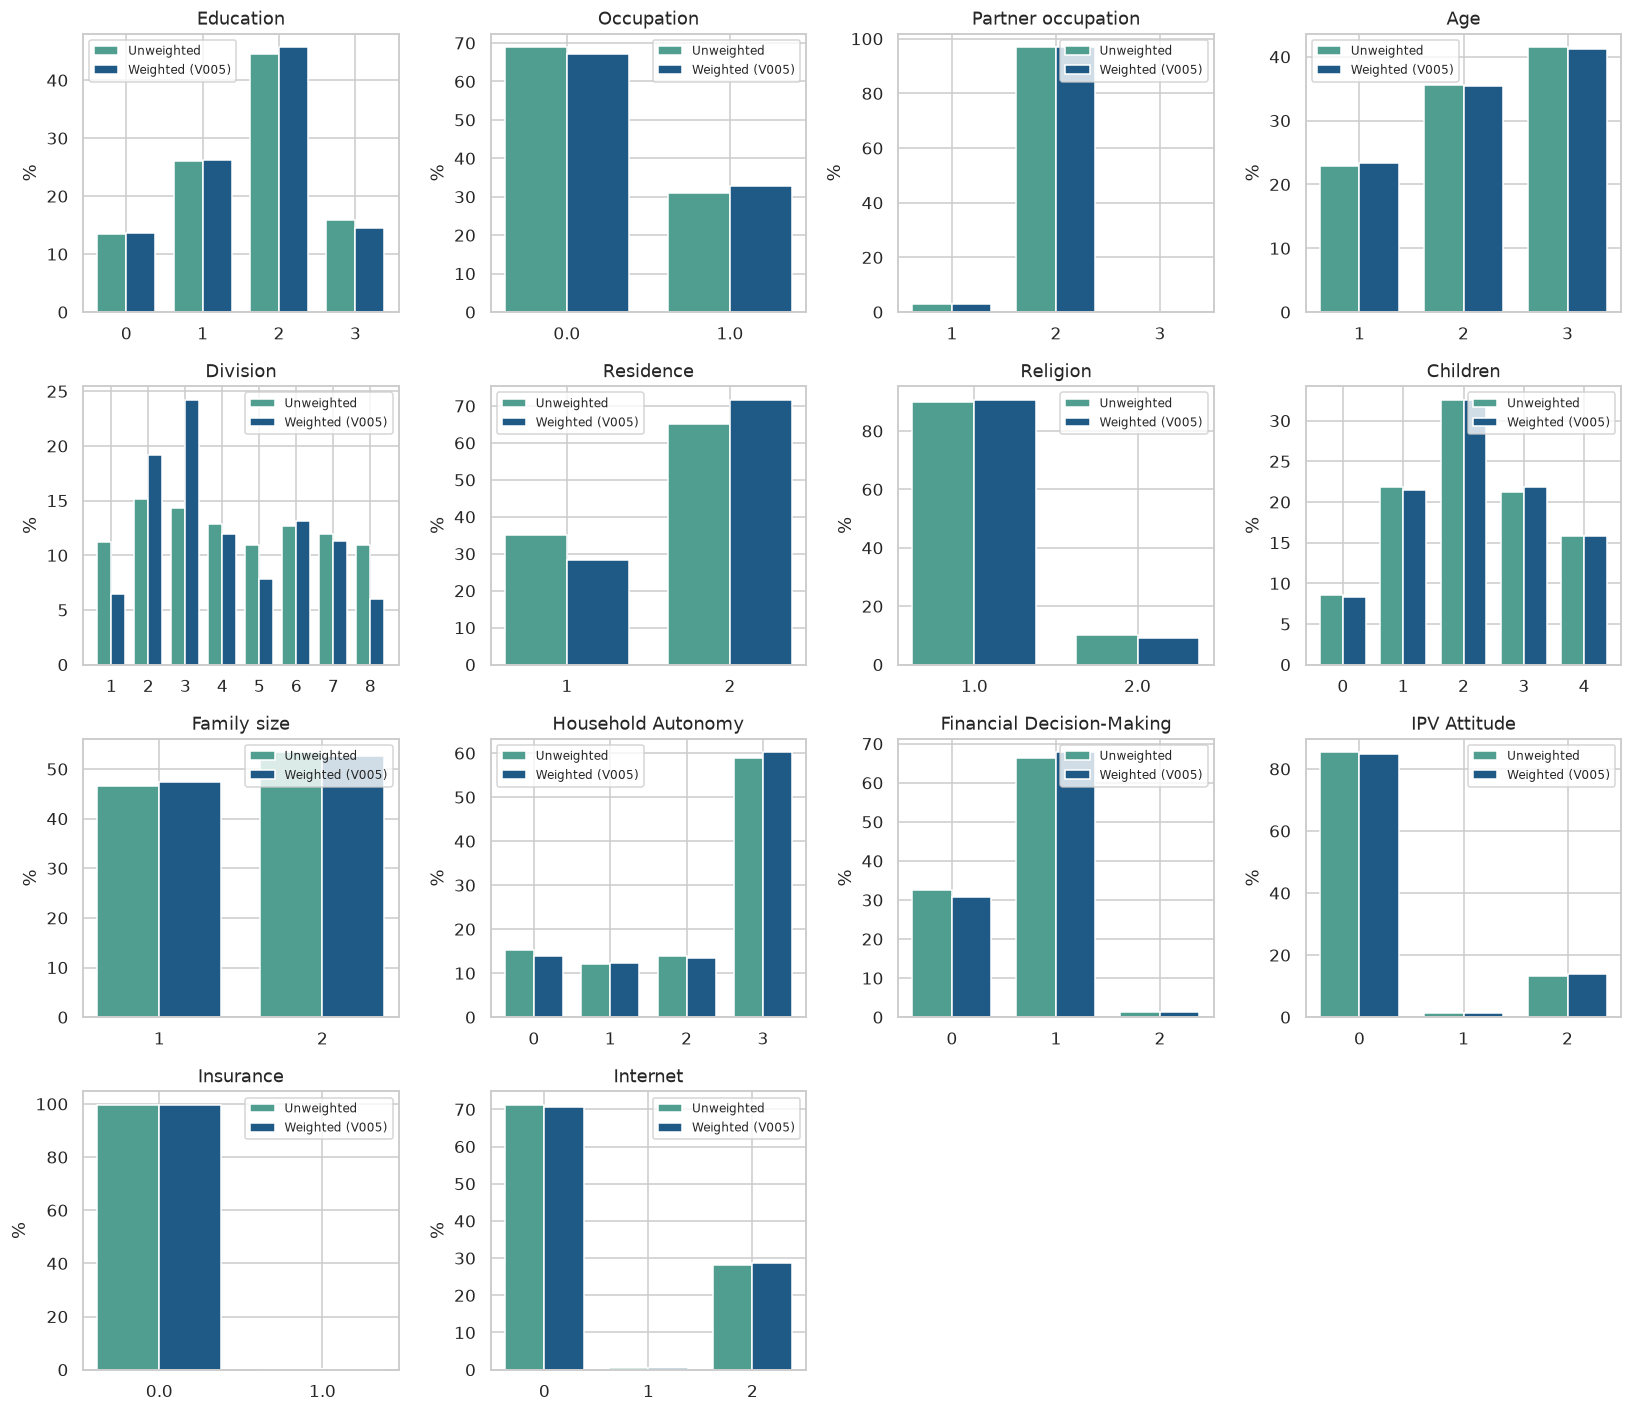

In [12]:
confounders = ["Education", "Occupation", "Partner occupation", "Age", "Division", "Residence",
               "Religion", "Children", "Family size", "Household Autonomy", "Financial Decision-Making",
               "IPV Attitude", "Insurance", "Internet"]

fig, axes = plt.subplots(4, 4, figsize=(15, 13))
axes = axes.flatten()
for i, col in enumerate(confounders):
    compare_bar(df_depression, col, axes[i], col)
for j in range(len(confounders), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

`Financial Decision-Making` and the 3-level `IPV Attitude` are both new to this section [NEW] — each has a small third category (no-earnings; uncertain) visible but not dominant, consistent with the counts confirmed in §2.1.

## 4. Bivariate Relationships and Cell Sparsity [re-verified, n changed]

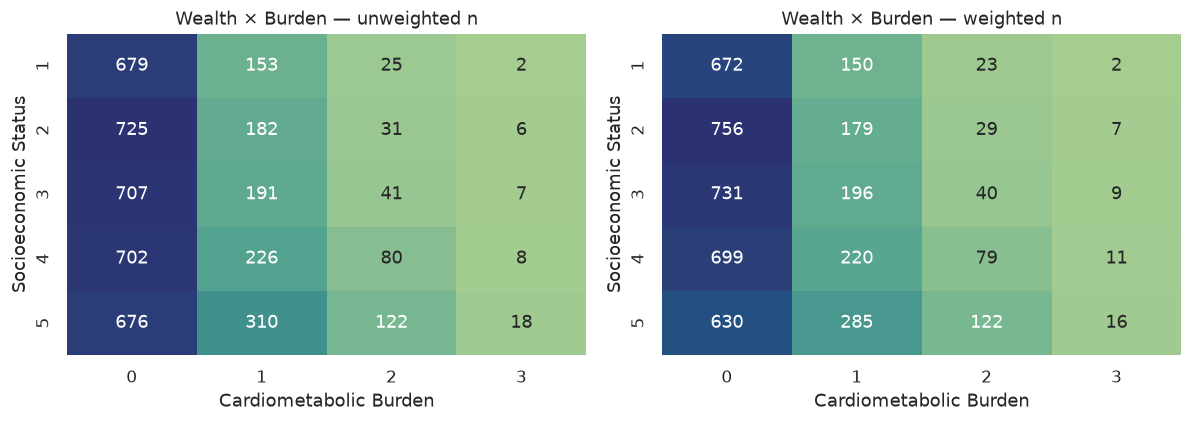

Smallest unweighted cell: 2


In [13]:
ct_unweighted = pd.crosstab(df_depression["Socioeconomic Status"], df_depression["Cardiometabolic Burden"])
ct_weighted = df_depression.pivot_table(index="Socioeconomic Status", columns="Cardiometabolic Burden",
                                         values="Sampling weight", aggfunc="sum")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(ct_unweighted, annot=True, fmt="d", cmap="crest", ax=axes[0], cbar=False)
axes[0].set_title("Wealth × Burden — unweighted n")
sns.heatmap(ct_weighted, annot=True, fmt=".0f", cmap="crest", ax=axes[1], cbar=False)
axes[1].set_title("Wealth × Burden — weighted n")
plt.tight_layout()
plt.show()

print("Smallest unweighted cell:", ct_unweighted.values.min())

Same sparsity concern as before: the highest-burden, lowest-wealth cell remains thin. The recommendation is unchanged — treat `Cardiometabolic Burden` as ordinal/linear in the interaction term, or collapse categories 2/3, rather than fitting a fully saturated categorical interaction.

In [14]:
cell3 = df_depression.groupby(["Socioeconomic Status", "Cardiometabolic Burden", "Depression"]).size()
print(f"3-way cells: {len(cell3)} total, {int((cell3 == 0).sum())} empty, "
      f"minimum non-empty count = {cell3[cell3 > 0].min()}")
print(f"Cells with count < 5: {int((cell3 < 5).sum())} / {len(cell3)}")

3-way cells: 71 total, 0 empty, minimum non-empty count = 1
Cells with count < 5: 24 / 71


In [15]:
def naive_chi2(data, a, b, label):
    tab = pd.crosstab(data[a], data[b])
    chi2, p, dof, _ = stats.chi2_contingency(tab)
    print(f"{label:35s}  chi2={chi2:8.2f}  df={dof:3d}  p={p:.4g}")

print("Design-naive Pearson chi-sq screening (NOT the reported statistic):\n")
naive_chi2(df_depression, "Socioeconomic Status", "Cardiometabolic Burden", "Wealth × Burden")
naive_chi2(df_depression, "Socioeconomic Status", "Depression", "Wealth × Depression")
naive_chi2(df_depression, "Cardiometabolic Burden", "Depression", "Burden × Depression")
naive_chi2(df_anxiety, "Socioeconomic Status", "Anxiety", "Wealth × Anxiety")
naive_chi2(df_anxiety, "Cardiometabolic Burden", "Anxiety", "Burden × Anxiety")

Design-naive Pearson chi-sq screening (NOT the reported statistic):

Wealth × Burden                      chi2=  150.82  df= 12  p=3.865e-26
Wealth × Depression                  chi2=   31.15  df= 16  p=0.01288
Burden × Depression                  chi2=   16.56  df= 12  p=0.1668
Wealth × Anxiety                     chi2=   41.61  df= 12  p=3.875e-05
Burden × Anxiety                     chi2=   12.11  df=  9  p=0.2072


## 5. Multicollinearity: Generalized VIF (Fox & Monette, 1992) [RESOLVED, re-run]

`Marital status` is gone from the pipeline entirely, so the degenerate-GVIF problem from the last pass can't recur — there's nothing to re-introduce it. Candidate covariate set below drops `Marital status` and renames `Autonomy` to `Household Autonomy`, otherwise unchanged from before (still the 12-covariate DAG-based adjustment set reconstructed from `Supplementary Figure S1 (Full DAG).tex`).

In [16]:
def calc_gvif(formula_rhs, data):
    '''Fox & Monette (1992) generalized VIF, one row per term.'''
    design = patsy.dmatrix(formula_rhs, data, return_type="dataframe")
    term_slices = design.design_info.term_name_slices
    X = design.drop(columns=["Intercept"], errors="ignore")
    R = X.corr().values
    detR = np.linalg.det(R)
    colnames = list(X.columns)

    rows = []
    for term, sl in term_slices.items():
        if term == "Intercept":
            continue
        cols = [c for c in design.columns[sl] if c != "Intercept"]
        idx = [colnames.index(c) for c in cols]
        other_idx = [i for i in range(len(colnames)) if i not in idx]
        d = len(idx)
        gvif = (np.linalg.det(R[np.ix_(idx, idx)]) * np.linalg.det(R[np.ix_(other_idx, other_idx)])) / detR
        rows.append((term.replace("C(Q('", "").replace("'))", ""), d, gvif, gvif ** (1 / (2 * d))))
    out = pd.DataFrame(rows, columns=["term", "Df", "GVIF", "GVIF^(1/(2*Df))"])
    return out.sort_values("GVIF^(1/(2*Df))", ascending=False).reset_index(drop=True)

exposure, modifier = "Socioeconomic Status", "Cardiometabolic Burden"
candidate_covariates = ["Education", "Occupation", "Partner occupation", "Age", "Division", "Residence",
                        "Religion", "Children", "Family size", "Household Autonomy", "Insurance", "Internet"]
model_vars = [exposure, modifier] + candidate_covariates
formula_rhs = " + ".join(f"C(Q('{v}'))" for v in model_vars)

gvif = calc_gvif(formula_rhs, df_depression[model_vars].dropna())
threshold = 2.0
gvif["flag"] = np.where(gvif["GVIF^(1/(2*Df))"] > threshold, "⚠ review", "OK")
gvif.style.format({"GVIF": "{:.3g}", "GVIF^(1/(2*Df))": "{:.3g}"})

,term,Df,GVIF,GVIF^(1/(2*Df)),flag
0,Age,2,2.18,1.22,OK
1,Children,4,2.34,1.11,OK
2,Education,3,1.85,1.11,OK
3,Residence,1,1.22,1.11,OK
4,Internet,2,1.39,1.09,OK
5,Family size,1,1.16,1.08,OK
6,Socioeconomic Status,4,1.79,1.08,OK
7,Occupation,1,1.1,1.05,OK
8,Cardiometabolic Burden,3,1.16,1.02,OK
9,Religion,1,1.05,1.02,OK


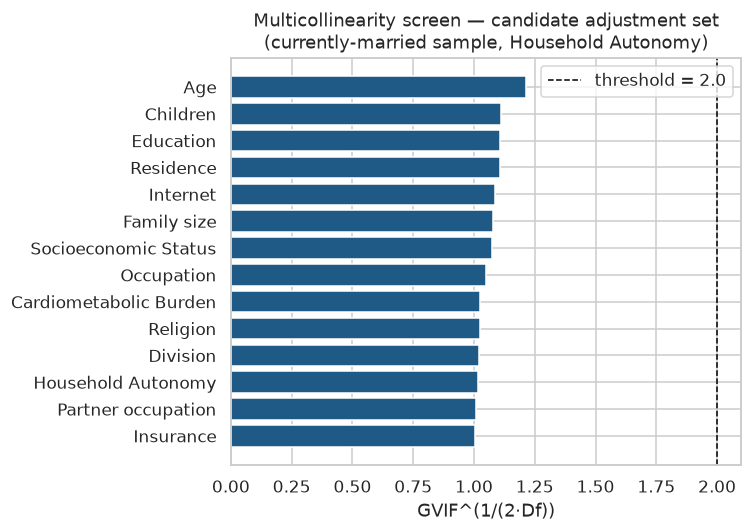

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
order = gvif.sort_values("GVIF^(1/(2*Df))")
colors = [PALETTE[6] if v <= threshold else "indianred" for v in order["GVIF^(1/(2*Df))"]]
ax.barh(order["term"], order["GVIF^(1/(2*Df))"], color=colors)
ax.axvline(threshold, color="black", linestyle="--", linewidth=1, label=f"threshold = {threshold}")
ax.set_xlabel("GVIF^(1/(2·Df))")
ax.set_title("Multicollinearity screen — candidate adjustment set\n(currently-married sample, Household Autonomy)")
ax.legend()
plt.tight_layout()
plt.show()

Clean across the board — no term exceeds the threshold. `Household Autonomy` in particular now sits with the rest of the well-behaved covariates rather than carrying the spurious tie to `Marital status` it had before the fix.

### 5.1 Where do `Financial Decision-Making` and the new `IPV Attitude` fit? [OPEN]

Neither variable was in the DAG-reconstructed 12-covariate adjustment set for the Wealth→Mental Health backdoor, so they aren't added to the candidate set above by default. `IPV Attitude` wasn't in it either in the previous pass — it enters the DAG as a cause of `Education` and `Mental Health`, not of `Wealth`, so it's not part of *this* backdoor set regardless of its don't-know handling. `Financial Decision-Making` is new; whether it belongs in the adjustment set (as a `Wealth` parent, alongside `Household Autonomy`) or stays a sensitivity-only variable is a DAG decision, not a multicollinearity one. Checked here only for whether adding it would *cause* a problem if you do decide to include it:

In [18]:
candidate_with_financial = candidate_covariates + ["Financial Decision-Making"]
model_vars_fd = [exposure, modifier] + candidate_with_financial
formula_rhs_fd = " + ".join(f"C(Q('{v}'))" for v in model_vars_fd)

gvif_fd = calc_gvif(formula_rhs_fd, df_depression[model_vars_fd].dropna())
gvif_fd["flag"] = np.where(gvif_fd["GVIF^(1/(2*Df))"] > threshold, "⚠ review", "OK")
gvif_fd.style.format({"GVIF": "{:.3g}", "GVIF^(1/(2*Df))": "{:.3g}"})

,term,Df,GVIF,GVIF^(1/(2*Df)),flag
0,Age,2,2.18,1.22,OK
1,Financial Decision-Making,2,1.83,1.16,OK
2,Children,4,2.34,1.11,OK
3,Education,3,1.86,1.11,OK
4,Residence,1,1.23,1.11,OK
5,Internet,2,1.39,1.09,OK
6,Household Autonomy,3,1.59,1.08,OK
7,Family size,1,1.16,1.08,OK
8,Socioeconomic Status,4,1.8,1.08,OK
9,Partner occupation,2,1.22,1.05,OK


No problem either way — `Financial Decision-Making` and `Household Autonomy` are correlated (both reflect the same underlying empowerment construct) but not collinear in the Marital-status sense. Adding it is a modeling choice, not something forced by this diagnostic.

### 5.2 Association overview (categorical correlation heatmap)

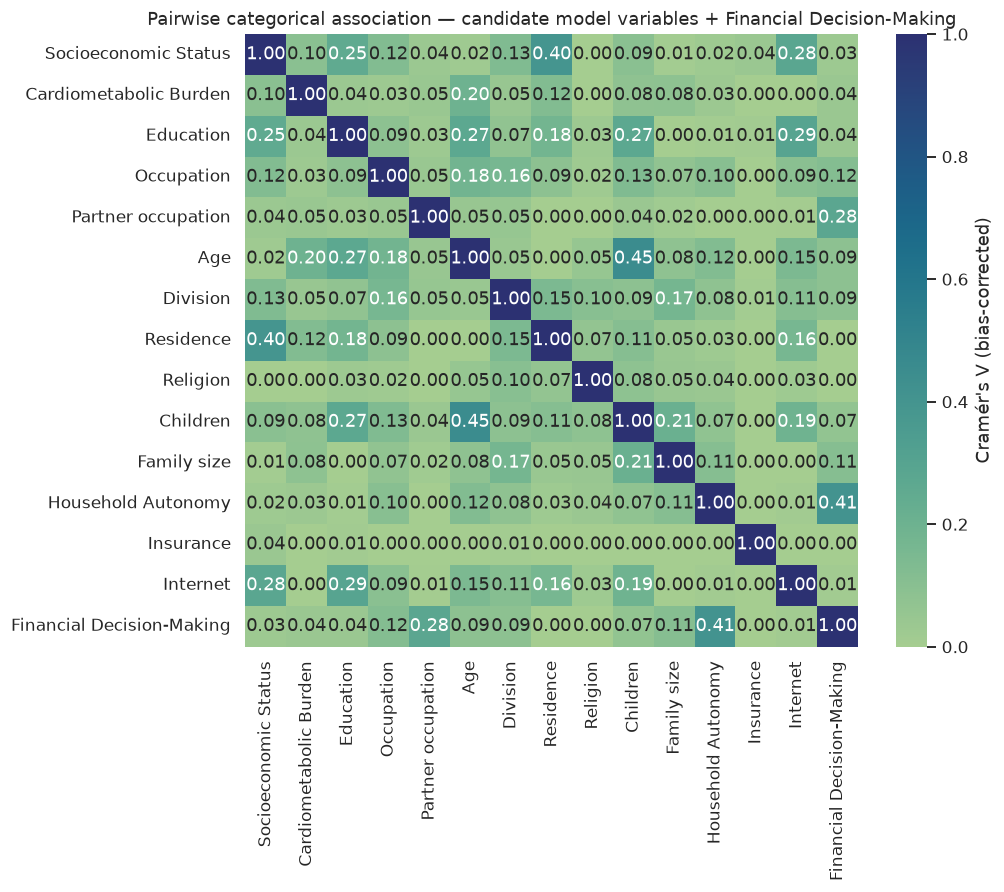

In [19]:
def cramers_v_corrected(x, y):
    tab = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tab)[0]
    n = tab.sum().sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

assoc_vars = model_vars_fd
assoc = pd.DataFrame(index=assoc_vars, columns=assoc_vars, dtype=float)
for a in assoc_vars:
    for b in assoc_vars:
        assoc.loc[a, b] = 1.0 if a == b else cramers_v_corrected(df_depression[a], df_depression[b])

fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(assoc.astype(float), annot=True, fmt=".2f", cmap="crest", vmin=0, vmax=1,
            square=True, cbar_kws={"label": "Cramér's V (bias-corrected)"}, ax=ax)
plt.title("Pairwise categorical association — candidate model variables + Financial Decision-Making")
plt.tight_layout()
plt.show()

## 6. Summary of Findings

| # | Finding | Status |
|---|---|---|
| A | Depression/Anxiety, Occupation, Insurance, and IPV-attitude items share the same "extended module" sub-sample as the biomarker components | Documentation note only — confirm §2.7 covers this |
| B | `Autonomy` silently recoded not-applicable cases to "0 = no autonomy" | **[RESOLVED]** `Household Autonomy` now built from `V743A`/`V743B`/`V743D` only; `V743F`'s "no earnings" case (64 women, 1.3%) preserved separately in `Financial Decision-Making` rather than discarded |
| C | `Marital status` / `Partner occupation` deterministic collinearity | **[RESOLVED]** `Marital status` dropped entirely — now constant under the currently-married-only filter |
| D | `Wealth=Poorest × Burden=3` interaction cell is thin | Still open — treat Burden as ordinal/linear in the interaction, or collapse 2/3 |
| E | `IPV Attitude` "don't know" silently absorbed into "No" | **[RESOLVED]** now a 3-level variable (Rejects/Uncertain/Justifies); 62 women (1.3%) newly distinguished as "Uncertain" |
| — | Whether `Financial Decision-Making` belongs in the primary adjustment set | **[OPEN]** — a DAG decision; confirmed not to introduce multicollinearity if added |

Sample size dropped from 5,137 to 4,891 with the ever-married → currently-married restriction (all excluded rows were the previously-flagged not-currently-married group). No missing data remains except the single previously-imputed Religion case. The candidate 12-covariate adjustment set clears GVIF^(1/(2·Df)) < 2 with no fix required this round — `Age` remains the highest term. Recommended before regression: decide on `Financial Decision-Making`'s place in the DAG, then proceed to the survey-weighted logistic models in R/Stata as planned.